## interpretacion

### By:
Maria Camila Sepulveda Torres

### Date:
2026-08-21



## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

## 💾 Load data

In [2]:
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

admission_model = load(DATA_MODEL / "ridge_optimized_pipeline.joblib")

print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


# interpretacion

##Feature importance

In [3]:
features = admission_model["preprocessor"].get_feature_names_out()
coefficients = admission_model["model"].coef_

df_features = pd.DataFrame(
    {
        "Features": features,
        "Coefficients": coefficients,
        "Absolute Importance": np.abs(coefficients),
    }
)

df_features = df_features.sort_values(
    by="Absolute Importance",
    ascending=False,
)

df_features

,Features,Coefficients,Absolute Importance
5,numeric__CGPA,0.063608,0.063608
1,numeric__TOEFL Score,0.024009,0.024009
0,numeric__GRE Score,0.023555,0.023555
6,categoric ordinal__Research,0.021768,0.021768
4,numeric__LOR,0.017425,0.017425
2,numeric__University Rating,0.002010,0.002010
3,numeric__SOP,0.001535,0.001535


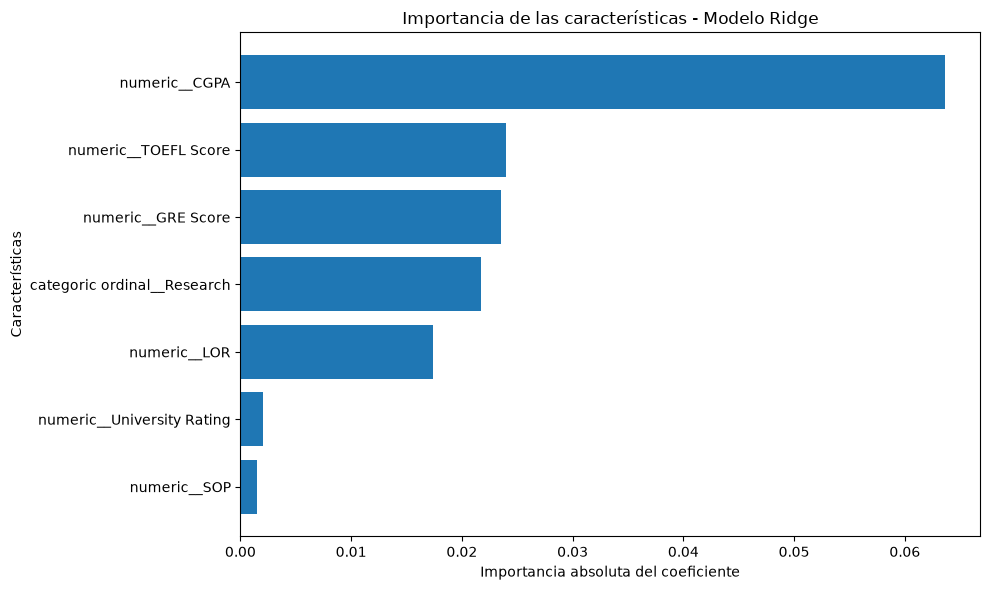

In [4]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_features["Features"],
    df_features["Absolute Importance"],
)

plt.xlabel("Importancia absoluta del coeficiente")
plt.ylabel("Características")
plt.title("Importancia de las características - Modelo Ridge")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación de la importancia de las características

La característica con mayor influencia en el modelo Ridge es **CGPA**, con un coeficiente de 0.0636, lo que indica que el desempeño académico acumulado tiene el mayor peso en la predicción de la probabilidad de admisión.

En un segundo grupo se encuentran **TOEFL Score (0.0240)**, **GRE Score (0.0236)** y **Research (0.0218)**, que también aportan información relevante a la predicción. Por su parte, **LOR (0.0174)** presenta una contribución menor.

Las características **University Rating (0.0020)** y **SOP (0.0015)** presentan los coeficientes de menor magnitud, por lo que su influencia en las predicciones del modelo es considerablemente menor.

Todos los coeficientes obtenidos son positivos, indicando que, manteniendo las demás características constantes, incrementos en estas variables se asocian con incrementos en la predicción de la probabilidad de admisión.

Debido a que el modelo Ridge utiliza regularización L2, los coeficientes son penalizados para reducir su magnitud y limitar el sobreajuste. Por esta razón, esta interpretación debe complementarse con técnicas como la importancia por permutación.

## Feature permutation

In [6]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(DATA_DIR / "02_intermediate" / "admission_type_fixed.parquet")

admission_df = admission_df.drop_duplicates()

admission_df.info()

<class 'pandas.DataFrame'>
Index: 471 entries, 0 to 581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          460 non-null    Int16  
 1   TOEFL Score        452 non-null    Int16  
 2   University Rating  465 non-null    float64
 3   SOP                455 non-null    float64
 4   LOR                463 non-null    float64
 5   CGPA               469 non-null    float64
 6   Research           442 non-null    boolean
 7   Chance of Admit    471 non-null    float64
dtypes: Int16(2), boolean(1), float64(5)
memory usage: 25.8 KB


In [7]:
X = admission_df.drop(columns=["Chance of Admit"])
y = admission_df["Chance of Admit"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (376, 7)
Test: (95, 7)


In [8]:
imps = permutation_importance(
    admission_model,
    x_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

df_permutation = pd.DataFrame(
    {
        "Features": x_test.columns,
        "Importances Mean": imps.importances_mean,
        "Importances STD": imps.importances_std,
    }
)

df_permutation = df_permutation.sort_values(
    by="Importances Mean",
    ascending=False,
)

df_permutation

,Features,Importances Mean,Importances STD
5,CGPA,0.045614,0.007093
0,GRE Score,0.007381,0.002061
1,TOEFL Score,0.004564,0.002259
4,LOR,0.004172,0.001830
6,Research,0.001281,0.001085
2,University Rating,0.000175,0.000158
3,SOP,-0.000049,0.000117


/tmp/ipykernel_13882/3457681930.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


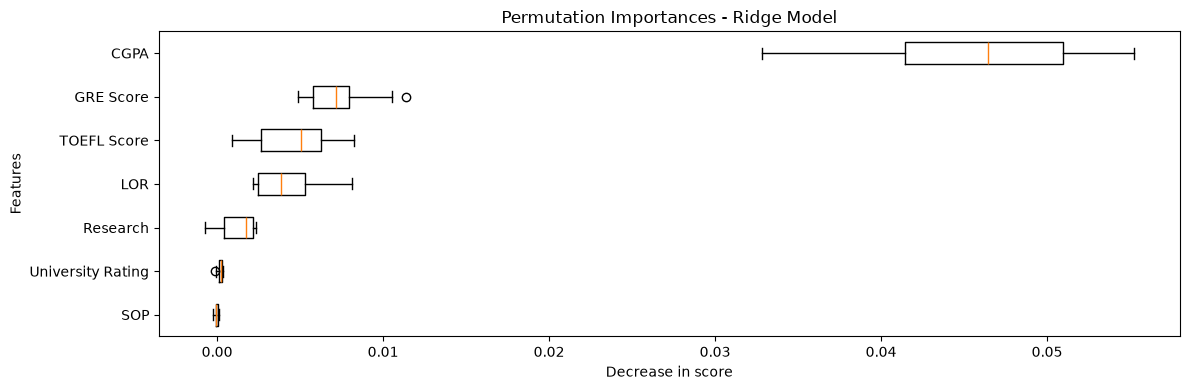

In [9]:
sorted_idx = imps.importances_mean.argsort()

plt.figure(figsize=(12, 4))
plt.boxplot(
    imps.importances[sorted_idx].T,
    vert=False,
    tick_labels=x_test.columns[sorted_idx],
)

plt.xlabel("Decrease in score")
plt.ylabel("Features")
plt.title("Permutation Importances - Ridge Model")
plt.tight_layout()
plt.show()

### Interpretación de la importancia por permutación

Los resultados de la importancia por permutación confirman que **CGPA** es la característica con mayor influencia sobre el desempeño predictivo del modelo Ridge. Su importancia media (0.0456) es considerablemente superior a la observada para las demás variables, lo que indica que alterar sus valores produce la mayor disminución en el desempeño del modelo.

En un segundo nivel se encuentran **GRE Score (0.0074)**, **TOEFL Score (0.0046)** y **LOR (0.0042)**. Estas características contribuyen al desempeño predictivo, aunque su efecto es considerablemente menor que el de CGPA. **Research (0.0013)** presenta una contribución más reducida.

Por su parte, **University Rating (0.0002)** y **SOP (-0.00005)** muestran una importancia cercana a cero. En particular, el valor ligeramente negativo de SOP no implica necesariamente un efecto perjudicial sobre el modelo, ya que su magnitud es mínima y se encuentra dentro de la variabilidad observada entre las permutaciones. Esto sugiere que SOP aporta poca información predictiva adicional en el conjunto de prueba.

En conjunto, la importancia por permutación respalda la interpretación obtenida mediante los coeficientes del modelo: el desempeño académico, particularmente **CGPA**, constituye el principal factor asociado con las predicciones de admisión realizadas por el modelo.